In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_train = pd.read_csv("/kaggle/input/spaceship-titanic/train.csv")
df_test = pd.read_csv("/kaggle/input/spaceship-titanic/test.csv")

In [3]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [4]:
df_train.head(1)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False


## 1.Some Eda before feture engineering

In [5]:
import math
def plot_all_pie(df, title_prefix=""):
    
    pie_cols = [col for col in df.columns if df[col].nunique() <= 10]
    
    n_cols = 3
    n_rows = math.ceil(len(pie_cols) / n_cols)
    
    plt.figure(figsize=(5 * n_cols, 5 * n_rows))
    
    for i, col in enumerate(pie_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        
        data = df[col].value_counts()
        
        plt.pie(data, 
                labels=data.index, 
                autopct='%1.1f%%', 
                startangle=140, 
                colors=sns.color_palette('flare'),
                wedgeprops={'edgecolor': 'white', 'linewidth': 2})
        
        plt.title(f"{title_prefix} {col} Distribution", fontsize=12, fontweight='bold')
        
    plt.tight_layout()

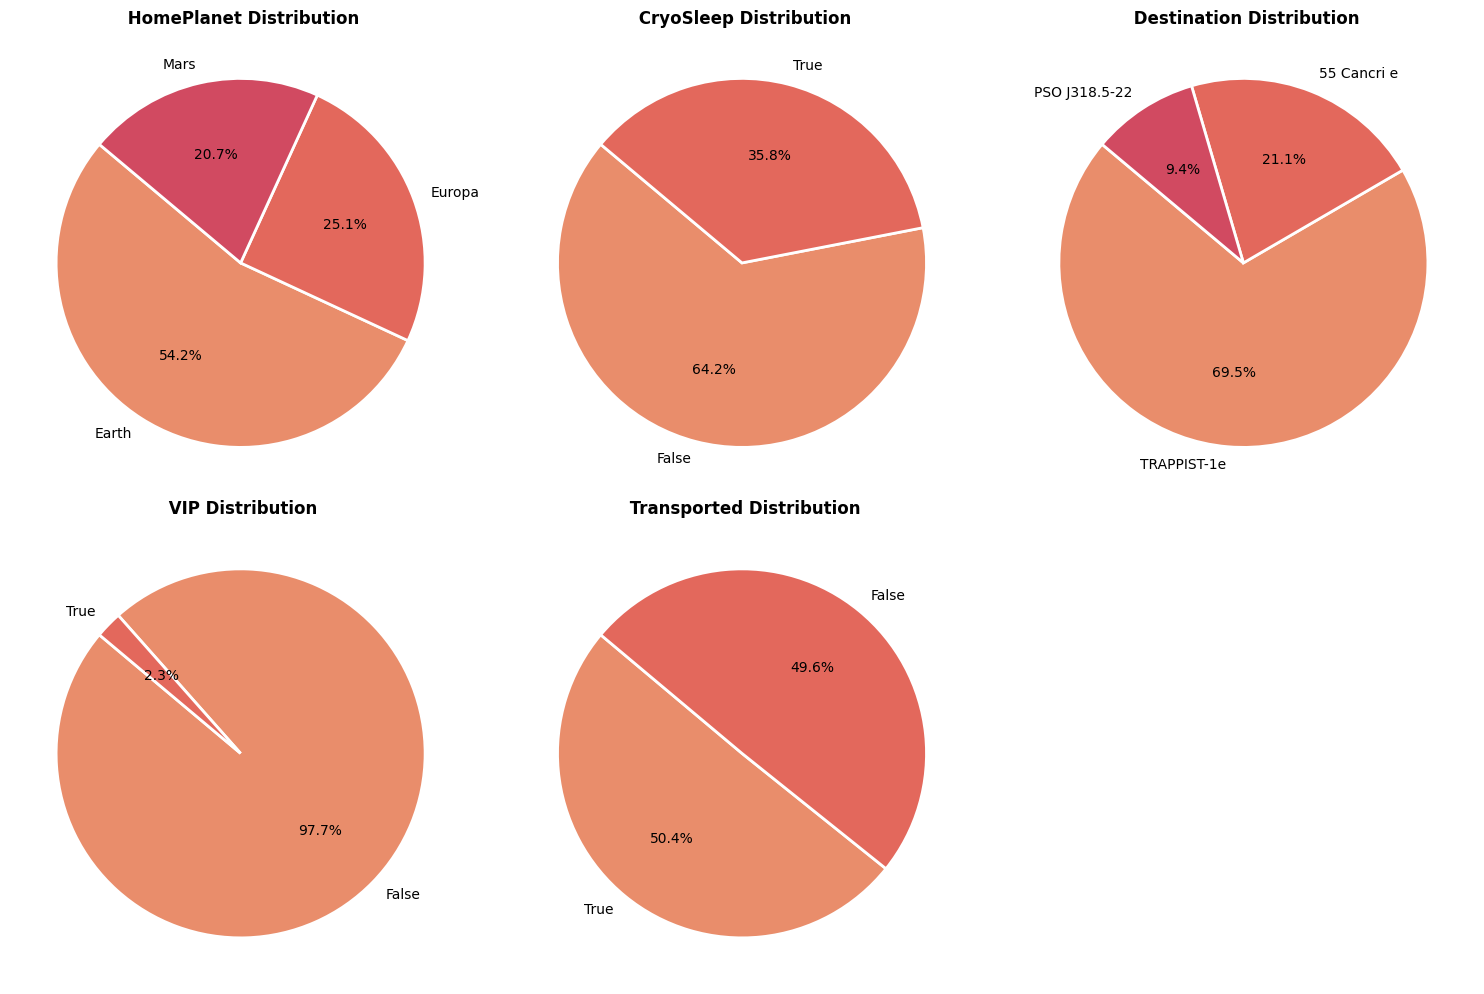

In [6]:
plot_all_pie(df_train)

In [7]:
target = 'Transported'
sorted_fetures_importances = (
    df_train.corr(numeric_only=True)[target]
    .abs()
    .sort_values(ascending=False)
    .drop(target)
)

In [8]:
sorted_fetures_importances

RoomService     0.244611
Spa             0.221131
VRDeck          0.207075
Age             0.075026
FoodCourt       0.046566
ShoppingMall    0.010141
Name: Transported, dtype: float64

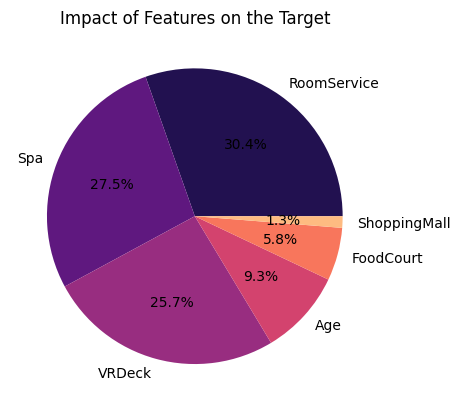

In [9]:
plt.pie(sorted_fetures_importances,
        labels=sorted_fetures_importances.index,
        colors=sns.color_palette('magma'),
        autopct='%1.1f%%', 
        
)
title= plt.title('Impact of Features on the Target')


plt.show()

In [10]:
df_train['Cabin']

0          B/0/P
1          F/0/S
2          A/0/S
3          A/0/S
4          F/1/S
          ...   
8688      A/98/P
8689    G/1499/S
8690    G/1500/S
8691     E/608/S
8692     E/608/S
Name: Cabin, Length: 8693, dtype: object

## 2.Feature engineering

In [11]:
df_train[['Deck','Num','Side']] = df_train['Cabin'].str.split('/',expand=True)
df_test[['Deck','Num','Side']] = df_test['Cabin'].str.split('/',expand=True)

In [12]:
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
df_train['TotalSpend'] = df_train[spend_cols].sum(axis=1)
df_test['TotalSpend'] = df_test[spend_cols].sum(axis=1)

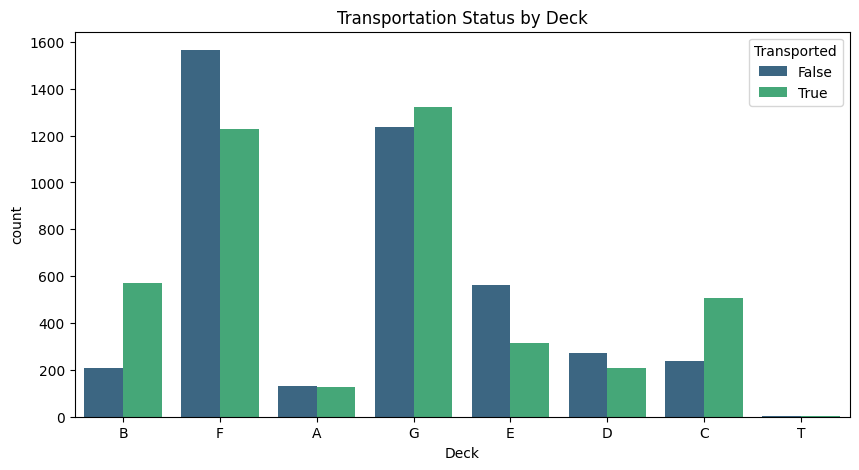

In [13]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df_train, x='Deck', hue='Transported', palette='viridis')
plt.title('Transportation Status by Deck')
plt.show()

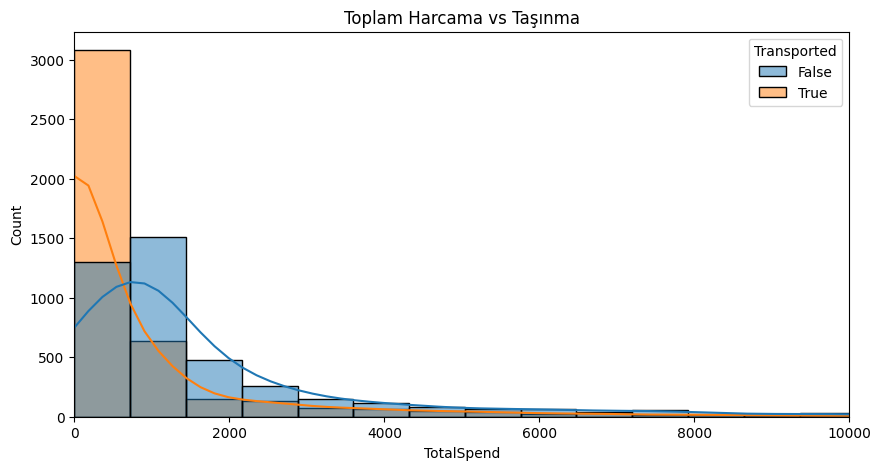

In [14]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df_train, x='TotalSpend', hue='Transported', bins=50, kde=True)
plt.xlim(0, 10000) 
plt.title('Toplam Harcama vs Taşınma')
plt.show()

In [15]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
 14  Deck          8494 non-null   object 
 15  Num           8494 non-null   object 
 16  Side          8494 non-null   object 
 17  TotalSpend    8693 non-null   float64
dtypes: bool(1), float64(7), obje

In [16]:
def fill_group_data(df):
    df['Group'] = df['PassengerId'].apply(lambda x: x.split('_')[0])
    
    df['HomePlanet'] = df['HomePlanet'].fillna(df.groupby('Group')['HomePlanet'].transform('first'))
    
    df['Destination'] = df['Destination'].fillna(df.groupby('Group')['Destination'].transform('first'))
    
    df['HomePlanet'] = df['HomePlanet'].fillna(df['HomePlanet'].mode()[0])
    df['Destination'] = df['Destination'].fillna(df['Destination'].mode()[0])
    
    return df

In [17]:
df_train = fill_group_data(df_train)
df_test = fill_group_data(df_test)

In [18]:
for df in [df_train,df_test]:
    df['TotalSpend'] = df[spend_cols].sum(axis=1)
    df['NoSpending']=(df['TotalSpend']==0).astype(int)
    df['LuxurySpend'] = df['Spa'] + df['VRDeck']

In [19]:
for df in [df_train, df_test]:
    df['Cabin'] = df['Cabin'].fillna('U/0/U')
    df['Deck'] = df['Cabin'].apply(lambda x: x.split('/')[0])
    df['Side'] = df['Cabin'].apply(lambda x: x.split('/')[2])

In [20]:
df_train[spend_cols] = df_train[spend_cols].fillna(0)
df_test[spend_cols] = df_test[spend_cols].fillna(0)

In [21]:
df_train['TotalSpend'] = df_train[spend_cols].sum(axis=1)
df_train['LuxurySpend'] = df_train['Spa'] + df_train['VRDeck']
df_test['TotalSpend'] = df_test[spend_cols].sum(axis=1)
df_test['LuxurySpend'] = df_test['Spa'] + df_test['VRDeck']

In [22]:
df_train.loc[(df_train['CryoSleep'].isnull()) & (df_train['TotalSpend']>0),'CryoSleep'] = False

In [23]:
df_test.loc[(df_test['CryoSleep'].isnull()) & (df_test['TotalSpend']>0),'CryoSleep'] = False

In [24]:
df_train['CryoSleep'] = df_train['CryoSleep'].fillna(df_train['CryoSleep'].mode()[0])
df_test['CryoSleep'] = df_test['CryoSleep'].fillna(df_test['CryoSleep'].mode()[0])

/tmp/ipykernel_17/3019620833.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train['CryoSleep'] = df_train['CryoSleep'].fillna(df_train['CryoSleep'].mode()[0])
/tmp/ipykernel_17/3019620833.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test['CryoSleep'] = df_test['CryoSleep'].fillna(df_test['CryoSleep'].mode()[0])


In [25]:
df_train.isna().sum()

PassengerId       0
HomePlanet        0
CryoSleep         0
Cabin             0
Destination       0
Age             179
VIP             203
RoomService       0
FoodCourt         0
ShoppingMall      0
Spa               0
VRDeck            0
Name            200
Transported       0
Deck              0
Num             199
Side              0
TotalSpend        0
Group             0
NoSpending        0
LuxurySpend       0
dtype: int64

In [26]:
df_train.drop('Name',axis=1,inplace=True)

In [27]:
df_test.drop('Name',axis=1,inplace=True)

In [28]:
df_train['Age'] = df_train['Age'].fillna(df_train['Age'].median())
df_test['Age'] = df_test['Age'].fillna(df_test['Age'].median())


In [29]:
df_train['VIP'] = df_train['VIP'].fillna(df_train['VIP'].mode()[0])
df_test['VIP'] = df_test['VIP'].fillna(df_test['VIP'].mode()[0])

/tmp/ipykernel_17/3749150200.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_train['VIP'] = df_train['VIP'].fillna(df_train['VIP'].mode()[0])
/tmp/ipykernel_17/3749150200.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_test['VIP'] = df_test['VIP'].fillna(df_test['VIP'].mode()[0])


In [30]:
temp_num_train = pd.to_numeric(df_train['Num'], errors='coerce')
temp_num_test = pd.to_numeric(df_test['Num'], errors='coerce')

df_train['Num'] = temp_num_train.fillna(temp_num_train.median())
df_test['Num'] = temp_num_test.fillna(temp_num_test.median())

In [31]:
df_train.isna().sum()

PassengerId     0
HomePlanet      0
CryoSleep       0
Cabin           0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Transported     0
Deck            0
Num             0
Side            0
TotalSpend      0
Group           0
NoSpending      0
LuxurySpend     0
dtype: int64

In [32]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 20 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8693 non-null   object 
 2   CryoSleep     8693 non-null   bool   
 3   Cabin         8693 non-null   object 
 4   Destination   8693 non-null   object 
 5   Age           8693 non-null   float64
 6   VIP           8693 non-null   bool   
 7   RoomService   8693 non-null   float64
 8   FoodCourt     8693 non-null   float64
 9   ShoppingMall  8693 non-null   float64
 10  Spa           8693 non-null   float64
 11  VRDeck        8693 non-null   float64
 12  Transported   8693 non-null   bool   
 13  Deck          8693 non-null   object 
 14  Num           8693 non-null   float64
 15  Side          8693 non-null   object 
 16  TotalSpend    8693 non-null   float64
 17  Group         8693 non-null   object 
 18  NoSpending    8693 non-null 

In [33]:
sorted_fetures_importances = (
    df_train.corr(numeric_only=True)[target]
    .abs()
    .sort_values(ascending=False)
    .drop(target)
)

In [34]:
sorted_fetures_importances

NoSpending      0.481628
CryoSleep       0.460132
LuxurySpend     0.279443
RoomService     0.241124
Spa             0.218545
VRDeck          0.204874
TotalSpend      0.199514
Age             0.074233
FoodCourt       0.045583
Num             0.044502
VIP             0.037261
ShoppingMall    0.009391
Name: Transported, dtype: float64

## 3.here we see feature importances

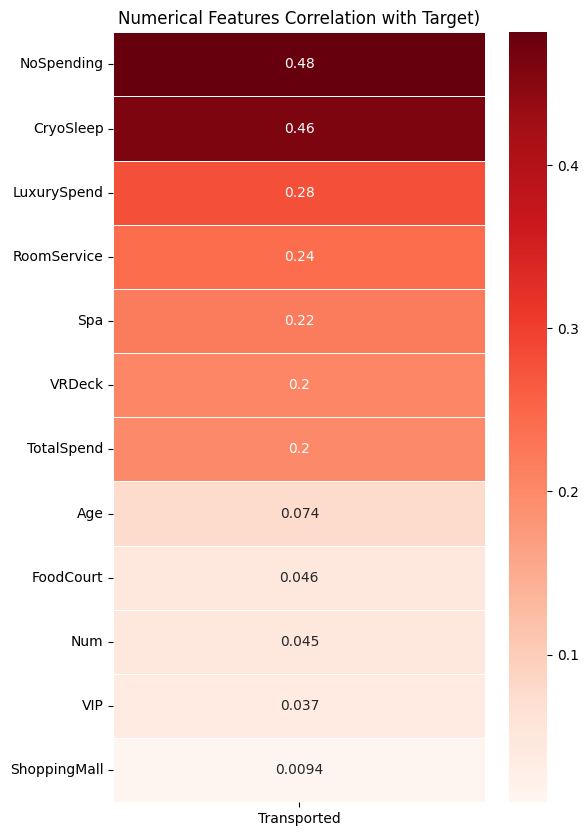

In [35]:
plt.figure(figsize=(6, 10))

sns.heatmap(
    sorted_fetures_importances.to_frame(), 
    annot=True, 
    cmap="Reds",     
    linewidths=0.4,
    cbar=True       
)

plt.title("Numerical Features Correlation with Target)")
plt.show()

In [36]:
def show_value_counts(df, cols):
    for col in cols:
        print(f"\n{col}")
        print('------------------')
        print(df[col].value_counts()
             )

In [37]:
cat_cols = [col for col in df_train.columns if df_train[col].dtype == "O"]
num_cols = [col for col in df_train.columns if df_train[col].dtype != "O"]

In [38]:
show_value_counts(df_train,cat_cols)


PassengerId
------------------
PassengerId
9280_02    1
0001_01    1
0002_01    1
0003_01    1
0003_02    1
          ..
0008_01    1
0007_01    1
0006_02    1
0006_01    1
0005_01    1
Name: count, Length: 8693, dtype: int64

HomePlanet
------------------
HomePlanet
Earth     4745
Europa    2161
Mars      1787
Name: count, dtype: int64

Cabin
------------------
Cabin
U/0/U       199
G/734/S       8
G/1368/P      7
G/109/P       7
C/21/P        7
           ... 
G/545/S       1
G/543/S       1
B/106/P       1
G/542/S       1
F/702/P       1
Name: count, Length: 6561, dtype: int64

Destination
------------------
Destination
TRAPPIST-1e      6072
55 Cancri e      1817
PSO J318.5-22     804
Name: count, dtype: int64

Deck
------------------
Deck
F    2794
G    2559
E     876
B     779
C     747
D     478
A     256
U     199
T       5
Name: count, dtype: int64

Side
------------------
Side
S    4288
P    4206
U     199
Name: count, dtype: int64

Group
------------------
Group
9081    8
40

## 4.hangling with cols which is we need no longer

In [39]:
df_train_id = df_train['PassengerId']
df_train.drop('PassengerId',axis=1,inplace=True)

df_test_id = df_test['PassengerId']
df_test.drop('PassengerId',axis=1,inplace=True)

In [40]:
df_train.drop('Cabin',axis=1,inplace=True)
df_test.drop('Cabin',axis=1,inplace=True)



In [41]:
df_train['Group_Size'] = df_train.groupby('Group')['Group'].transform('count')
df_test['Group_Size'] = df_test.groupby('Group')['Group'].transform('count')

In [42]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HomePlanet    8693 non-null   object 
 1   CryoSleep     8693 non-null   bool   
 2   Destination   8693 non-null   object 
 3   Age           8693 non-null   float64
 4   VIP           8693 non-null   bool   
 5   RoomService   8693 non-null   float64
 6   FoodCourt     8693 non-null   float64
 7   ShoppingMall  8693 non-null   float64
 8   Spa           8693 non-null   float64
 9   VRDeck        8693 non-null   float64
 10  Transported   8693 non-null   bool   
 11  Deck          8693 non-null   object 
 12  Num           8693 non-null   float64
 13  Side          8693 non-null   object 
 14  TotalSpend    8693 non-null   float64
 15  Group         8693 non-null   object 
 16  NoSpending    8693 non-null   int64  
 17  LuxurySpend   8693 non-null   float64
 18  Group_Size    8693 non-null 

In [43]:
df_train.drop('Group',axis=1,inplace=True)
df_test.drop('Group',axis=1,inplace=True)

In [44]:
cols_to_encode = ['HomePlanet', 'Destination', 'Side', 'Deck']
df_train = pd.get_dummies(df_train, columns=cols_to_encode)
df_test = pd.get_dummies(df_test, columns=cols_to_encode)

In [45]:
bool_cols = ['CryoSleep', 'VIP']
for col in bool_cols:
    df_train[col] = df_train[col].astype(int)
    df_test[col] = df_test[col].astype(int)

In [46]:
df_train['Transported'] = df_train['Transported'].astype(int)

In [47]:
df_train['Is_Child'] = (df_train['Age'] <= 12).astype(int)
df_test['Is_Child'] = (df_test['Age'] <= 12).astype(int)

In [48]:
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'TotalSpend']

In [49]:
for col in spend_cols:
    df_train[f'{col}_Log'] = np.log1p(df_train[col])
    df_test[f'{col}_Log'] = np.log1p(df_test[col])

In [50]:
from sklearn.model_selection import train_test_split

## 5.training models

In [51]:
X = df_train.drop('Transported',axis=1)
y = df_train['Transported']

In [52]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.3,
    random_state=42
)


In [53]:
from sklearn.preprocessing import StandardScaler

In [54]:
df_test

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Num,TotalSpend,...,Deck_G,Deck_T,Deck_U,Is_Child,RoomService_Log,FoodCourt_Log,ShoppingMall_Log,Spa_Log,VRDeck_Log,TotalSpend_Log
0,1,27.0,0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,...,True,False,False,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0,19.0,0,0.0,9.0,0.0,2823.0,0.0,4.0,2832.0,...,False,False,False,0,0.000000,2.302585,0.000000,7.945910,0.000000,7.949091
2,1,31.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,0,38.0,0,0.0,6652.0,0.0,181.0,585.0,1.0,7418.0,...,False,False,False,0,0.000000,8.802823,0.000000,5.204007,6.373320,8.911800
4,0,20.0,0,10.0,0.0,635.0,0.0,0.0,5.0,645.0,...,False,False,False,0,2.397895,0.000000,6.455199,0.000000,0.000000,6.470800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4272,1,34.0,0,0.0,0.0,0.0,0.0,0.0,1496.0,0.0,...,True,False,False,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4273,0,42.0,0,0.0,847.0,17.0,10.0,144.0,442.0,1018.0,...,False,False,True,0,0.000000,6.742881,2.890372,2.397895,4.976734,6.926577
4274,1,26.0,0,0.0,0.0,0.0,0.0,0.0,296.0,0.0,...,False,False,False,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4275,0,26.0,0,0.0,2680.0,0.0,0.0,523.0,297.0,3203.0,...,False,False,False,0,0.000000,7.893945,0.000000,0.000000,6.261492,8.072155


In [55]:
df_test_id

0       0013_01
1       0018_01
2       0019_01
3       0021_01
4       0023_01
         ...   
4272    9266_02
4273    9269_01
4274    9271_01
4275    9273_01
4276    9277_01
Name: PassengerId, Length: 4277, dtype: object

In [56]:
df_test_cols = df_test.columns

In [57]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
df_test = scaler.transform(df_test)

In [58]:
df

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Deck,Num,Side,TotalSpend,NoSpending,LuxurySpend,Group_Size
0,Earth,True,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,G,3.0,S,0.0,1,0.0,1
1,Earth,False,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,F,4.0,S,2832.0,0,2823.0,1
2,Europa,True,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,C,0.0,S,0.0,1,0.0,1
3,Europa,False,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,C,1.0,S,7418.0,0,766.0,1
4,Earth,False,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,F,5.0,S,645.0,0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4272,Earth,True,TRAPPIST-1e,34.0,False,0.0,0.0,0.0,0.0,0.0,G,1496.0,S,0.0,1,0.0,2
4273,Earth,False,TRAPPIST-1e,42.0,False,0.0,847.0,17.0,10.0,144.0,U,442.0,U,1018.0,0,154.0,1
4274,Mars,True,55 Cancri e,26.0,False,0.0,0.0,0.0,0.0,0.0,D,296.0,P,0.0,1,0.0,1
4275,Europa,False,TRAPPIST-1e,26.0,False,0.0,2680.0,0.0,0.0,523.0,D,297.0,P,3203.0,0,523.0,1


In [59]:
df_test = pd.DataFrame(df_test,columns=df_test_cols)
X_train = pd.DataFrame(X_train,columns=X.columns)
X_test = pd.DataFrame(X_test,columns=X.columns)

In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

ratio = 19

models_classification = {
    'Logistic Regression': LogisticRegression(class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced'),
    'Random Forest': RandomForestClassifier(class_weight='balanced'),
    'Extra Trees': ExtraTreesClassifier(class_weight='balanced'),
    
    'KNN Classifier': KNeighborsClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    
    'XGBoost': XGBClassifier(scale_pos_weight=ratio),
    'LightGBM': LGBMClassifier(is_unbalance=True, verbose=0),
    'CatBoost': CatBoostClassifier(auto_class_weights='Balanced', verbose=0)
}

In [61]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix


In [62]:
def evaluate_scores(true,predicted):
    accuracy = accuracy_score(true,predicted)
    report  = classification_report(true,predicted)
    matrix = confusion_matrix(true,predicted)
    
    return accuracy,report,matrix

In [63]:
for i in range(len(list(models_classification))):
    model = list(models_classification.values())[i]
    model.fit(X_train,y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_accuracy,train_report,train_matrix = evaluate_scores(y_train,y_train_pred)
    test_accuracy,test_report,test_matrix = evaluate_scores(y_test,y_test_pred)

    print(list(models_classification.keys())[i])
    print('model performance for Training Set')
    print('Root accuracy: ',train_accuracy)
    print(train_report)
    print(train_matrix)
    print('-------------------------------')
    print('model performance for Test Set')
    print('Test accuracy: ',test_accuracy)
    print(test_report)
    print(test_matrix)
    print('******************************')
    print('******************************')

Logistic Regression
model performance for Training Set
Root accuracy:  0.800821692686935
              precision    recall  f1-score   support

           0       0.82      0.77      0.79      3026
           1       0.79      0.83      0.81      3059

    accuracy                           0.80      6085
   macro avg       0.80      0.80      0.80      6085
weighted avg       0.80      0.80      0.80      6085

[[2337  689]
 [ 523 2536]]
-------------------------------
model performance for Test Set
Test accuracy:  0.786042944785276
              precision    recall  f1-score   support

           0       0.81      0.74      0.77      1289
           1       0.76      0.83      0.80      1319

    accuracy                           0.79      2608
   macro avg       0.79      0.79      0.79      2608
weighted avg       0.79      0.79      0.79      2608

[[ 950  339]
 [ 219 1100]]
******************************
******************************
Decision Tree
model performance for Training

## 6.models comparison

/tmp/ipykernel_17/3628603924.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Test Accuracy', y='Model', data=df_results, palette='magma')


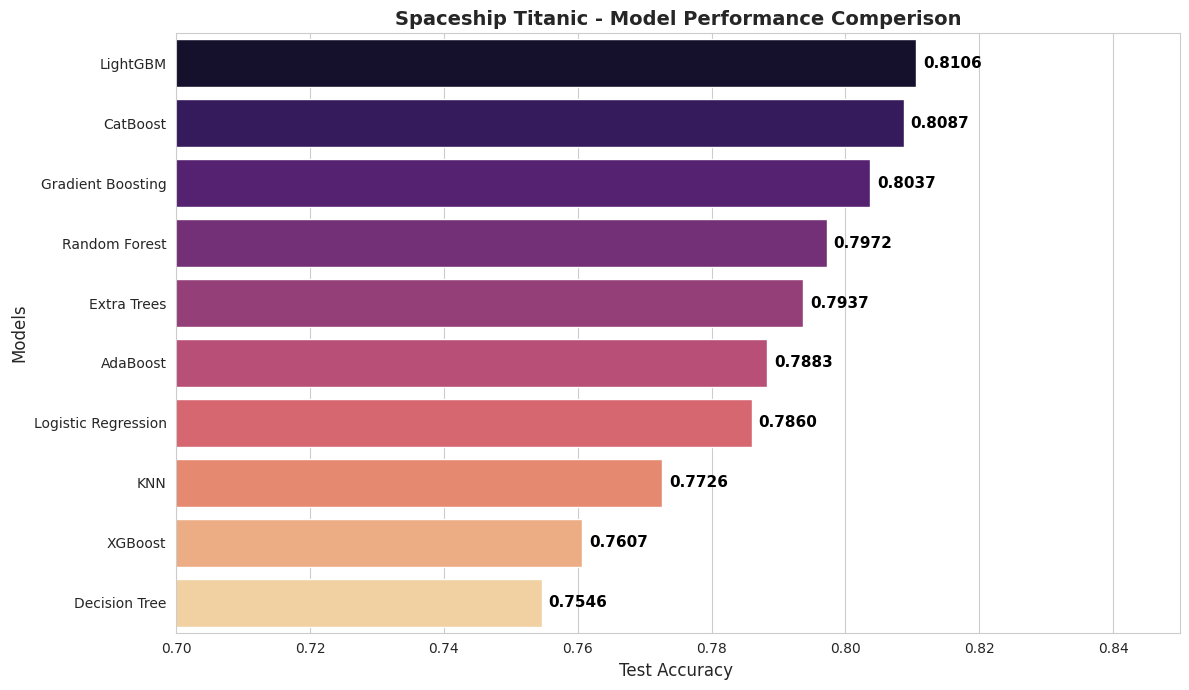

In [64]:

data = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Extra Trees', 
              'KNN', 'AdaBoost', 'Gradient Boosting', 'XGBoost', 'LightGBM', 'CatBoost'],
    'Test Accuracy': [0.7860, 0.7546, 0.7972, 0.7937, 
                      0.7726, 0.7883, 0.8037, 0.7607, 0.8106, 0.8087]
}

df_results = pd.DataFrame(data).sort_values(by='Test Accuracy', ascending=False)

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

ax = sns.barplot(x='Test Accuracy', y='Model', data=df_results, palette='magma')

plt.title('Spaceship Titanic - Model Performance Comperison', fontsize=14, fontweight='bold')
plt.xlabel('Test Accuracy ', fontsize=12)
plt.ylabel('Models', fontsize=12)

plt.xlim(0.70, 0.85)

for i, v in enumerate(df_results['Test Accuracy']):
    ax.text(v + 0.001, i, f'{v:.4f}', color='black', va='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

In [65]:
cady = CatBoostClassifier(
    random_state=42,
    verbose=0,             
    iterations=2000,       
    learning_rate=0.01,     
    depth=6,               
    l2_leaf_reg=3,   
    loss_function='Logloss',
    eval_metric='Accuracy', 
)

In [66]:
cady.fit(X_train,y_train)
y_pred2 = cady.predict(df_test)

submission = pd.DataFrame({
    'PassengerId': df_test_id,
    'Transported': y_pred2.astype(bool)
})

submission.to_csv('submission_with_cady_new.csv', index=False)